# <span style="color:blue"> GALAXY MODEL  gruppo G<span>

## Imports and setup

In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import emcee
import corner
from time import time

%matplotlib widget
plt.close("all")

## Data loading, filtering and unit conversion

In [2]:
# load the data and filter it by only picking stars near the equatorial plane (|b| < 5 deg)
gaia = Table.read("d3.gz")
mask = abs(gaia['b']) < 5
gaia_filtered = gaia[mask]

# note: we should also filter by parallax error if we dind't do it in the query!!!!

# extract the relevant columns
l = gaia_filtered["l"]
b = gaia_filtered["b"]
parallax = gaia_filtered["parallax"]
parallax_error = gaia_filtered["parallax_error"]
radial_velocity = gaia_filtered["radial_velocity"]
radial_velocity_error = gaia_filtered["radial_velocity_error"]

# print table info
gaia.info

<Table length=349153>
         name          dtype    unit                  description                 n_bad
--------------------- ------- -------- ------------------------------------------ -----
                   ra float64      deg                            Right ascension     0
                  dec float64      deg                                Declination     0
             parallax float64      mas                                   Parallax     0
       parallax_error float64      mas                 Standard error of parallax     0
                 pmra float64 mas / yr Proper motion in right ascension direction     0
                pmdec float64 mas / yr     Proper motion in declination direction     0
      phot_g_mean_mag float32      mag                      G-band mean magnitude     0
     phot_bp_mean_mag float32      mag               Integrated BP mean magnitude   422
     phot_rp_mean_mag float32      mag               Integrated RP mean magnitude   426
      radi

In [3]:
# unit conversion:
#   [velocity] = km/s
#   [distance] = kpc
#   [longitude/latitude] = radians

d_from_sun = 1 / parallax # distance from sun in kpc
l_rad = np.radians(l) # longitude in radians
b_rad = np.radians(b) # latitude in radians

print(f"Number of stars: {len(d_from_sun)}")

Number of stars: 75659


## Model definition and naive comparison

In [4]:
def distance_from_gc(l_rad, d_from_sun, R0):
    """Calculate the distance of a star from the galactic center given its longitude, distance from the sun, and the sun's distance from the galactic center.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc

        Returns:
        distance from the galactic center in kpc
    """
    return np.sqrt(R0**2 + d_from_sun**2 - 2.0*R0*d_from_sun*np.cos(l_rad))

def velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0):
    """Calculate the expected radial velocity of a star given its longitude, distance from the sun, and the model parameters.
d_from_sun
        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        U0: solar motion in the radial direction in km/s
        V0: solar motion in the tangential direction in km/s

        Returns:
        expected radial velocity in km/s

    """

    R = distance_from_gc(l_rad, d_from_sun, R0)
    
    V_lsr_term = U0 * np.cos(l_rad) + V0 * np.sin(l_rad)
    
    V_rot_term = V_rot*((1.0 / R) - (1.0 / R0))*R0*np.sin(l_rad)

    return V_rot_term + V_lsr_term

def model_derivative(l_rad, R0, V_rot, distance_from_sun, R, parallax):
    """ Calculate the derivative of the model with respect to the paralllax, needed to propagate the error
    
        Parameters:
        l_rad: longitude in radians
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        distance_from_sun: distance from the sun in kpc
        R: distance from the galactic center in kpc
        parallax: parallax in mas

        Returns:
        derivative of the model with respect to the parallax in km/s/mas
    """

    dD_dparallax = -1 / parallax**2 # derivative of distance from the sun with respect to parallax
    dR_dD = (distance_from_sun - R0*np.cos(l_rad)) / np.sqrt(R0**2 + distance_from_sun**2 - 2*R0*distance_from_sun*np.cos(l_rad)) # derivative of distance from the galactic center with respect to distance from the sun
    dV_dR = -V_rot / R**2 * R0 * np.sin(l_rad) # derivative of the model with respect to distance from the galactic center

    return dV_dR * dR_dD * dD_dparallax


R0 = 8.0 # kpc

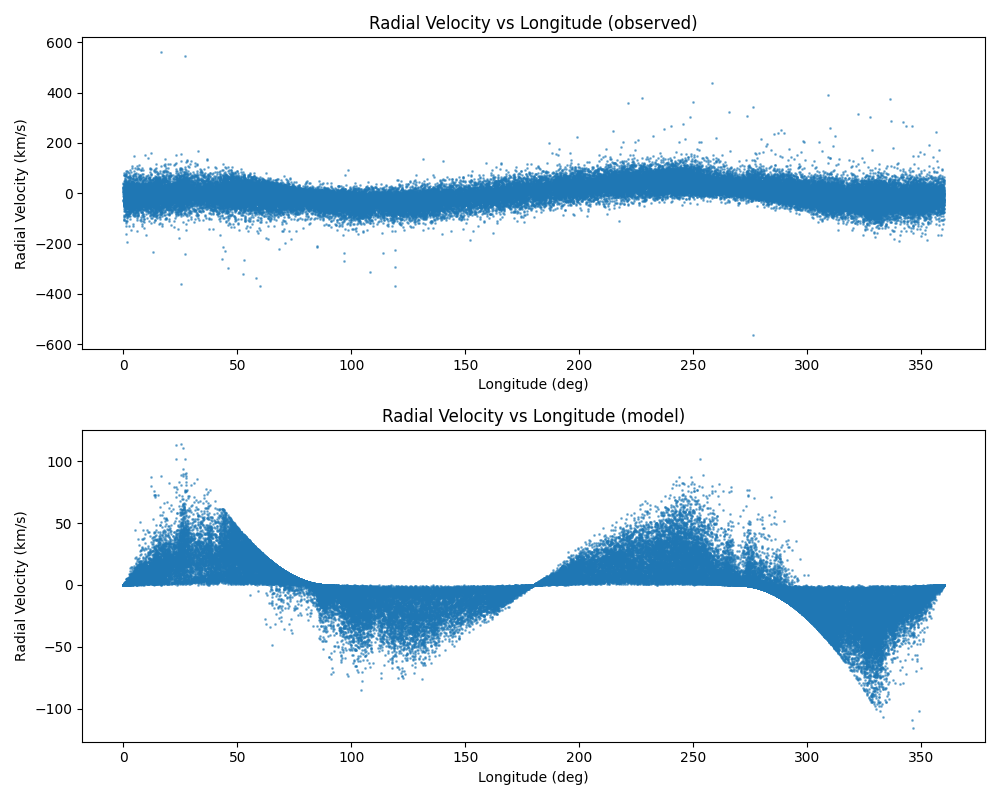

In [5]:
# plot the actual vs expected radial velocities for some initial guess of the parameters
# the lsr term for now is 0

V_rot = 200.0 # km/s
U0 = 0.0 # km/s
V0 = 0.0 # km/s

V_rad_exp = velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (observed)")

plt.subplot(2, 1, 2)
plt.scatter(l, V_rad_exp, s=1, label="Expected", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (model)")

plt.tight_layout()

plt.show()

## Statistical analysis

### Probability

In [6]:
def log_likelihood(theta, V_rad, l, d, v_rad_error, parallax_error):
    #print(f"theta shape: {theta.shape}")
    #print(f"theta: {theta}")
    V_rot, U0, V0 = theta

    #print(f"V_rot: {V_rot}, f: {f}, U0: {U0}, V0: {V0}")
    
    R = distance_from_gc(l, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, d, R0, V_rot, U0, V0)

    sigma2 = v_rad_error**2 + (model_derivative(l_rad, R0, V_rot, d, R, parallax) * parallax_error)**2

    return -np.sum(np.log(np.sqrt(2.0*np.pi*sigma2)) + (0.5*(V_rad - model)**2)/sigma2)

def log_prior(theta):
    V_rot, U0, V0 = theta

    # set the prior to be uniform, but set some bounds on the parameters

    if 0.0 < V_rot < 400.0:
        if -50.0 < U0 < 50.0:
            if -50.0 < V0 < 50.0:
                return 0.0
            
    return -np.inf

def log_probability(theta, V_rad, l, d, v_rad_error, parallax_error):
    log_like = log_likelihood(theta, V_rad, l, d, v_rad_error, parallax_error)
    log_pri = log_prior(theta)

    if not np.isfinite(log_like) or not np.isfinite(log_pri):
        return -np.inf

    return log_like + log_pri

In [7]:
# vectorized version of log_probability for emcee with vectorize=True, which allows us to evaluate the log-probability for multiple sets of parameters at once (one for each walker)

def log_likelihood_vect(theta, V_rad, l, d, v_rad_error, parallax_error, V_rot_fixed):
    # theta is formatted as ((V_rot1, U01, V01), (V_rot2, U02, V02), ...)
    V_rot = theta[:, 0][:, np.newaxis]   # (nwalkers, 1)
    U0    = theta[:, 1][:, np.newaxis]
    V0    = theta[:, 2][:, np.newaxis]

    R = distance_from_gc(l, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, d, R0, V_rot, U0, V0)

    sigma2 = v_rad_error**2 + (model_derivative(l, R0, V_rot_fixed, d, R, parallax) * parallax_error)**2

    # return value should be an array of log-likelihoods, one for each set of parameters in theta
    return -np.sum(0.5 * np.log(2.0 * np.pi * sigma2) + 0.5 * (V_rad - model)**2 / sigma2, axis=1)

def log_prior_vect(theta):
    V_rot = theta[:, 0]
    U0 = theta[:, 1]
    V0 = theta[:, 2]

    # set the prior to be uniform, but set some bounds on the parameters

    mask = (0.0 < V_rot) & (V_rot < 400.0) & (-50.0 < U0) & (U0 < 50.0) & (-50.0 < V0) & (V0 < 50.0)

    log_pri = np.full(theta.shape[0], -np.inf)
    log_pri[mask] = 0.0

    return log_pri

def log_probability_vect(theta, V_rad, l, d, v_rad_error, parallax_error, V_rot_fixed):
    log_pri = log_prior_vect(theta)
    log_prob = np.full(theta.shape[0], -np.inf)

    valid = np.isfinite(log_pri)

    if np.any(valid):
        log_prob[valid] = log_likelihood_vect(
            theta[valid], V_rad, l, d, v_rad_error, parallax_error, V_rot_fixed
        ) + log_pri[valid]
        
    return log_prob

### Max likelyhood

We first do a short run to get a reasonable estimate for a v_rot to use for error propagation. This run uses the initial guess for this purpose.
We extract this first estimate for V_rot as an average over the last samples of the chain (to exclude autocorrelated values)

100%|██████████| 100/100 [00:10<00:00,  9.19it/s]


(2880, 3)
V_rot guess: 209.44580300121592


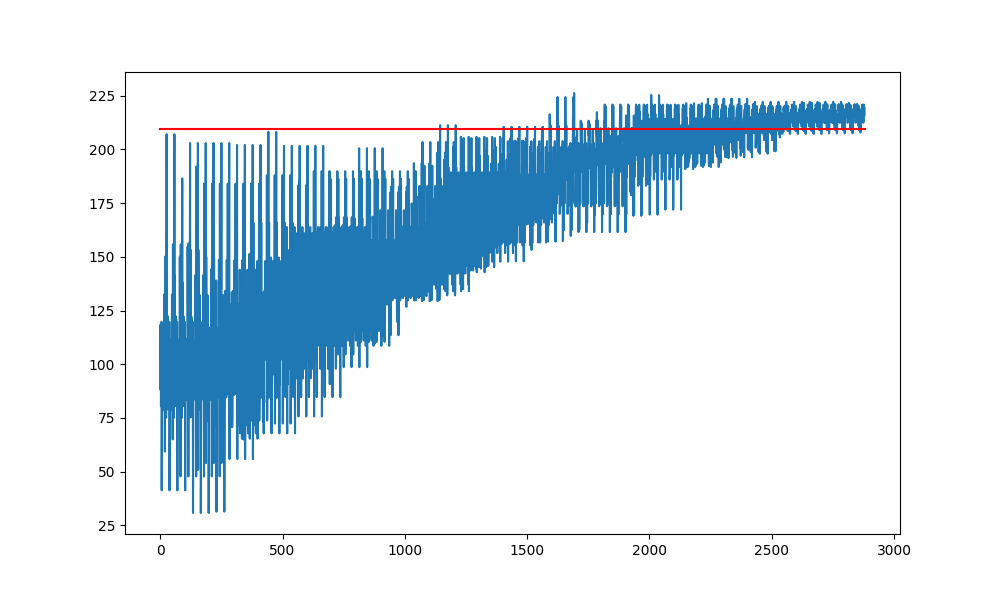

In [8]:
# initial guess for the parameters
# we set some reasonable start values (well inside the prior bounds), then add some random noise to create the initial positions of the walkers
p0 = [100.0, 10, 10] # initial guess for the parameters
pos = p0 + np.array([10.0, 5.0, 5.0]) * np.random.randn(32, 3)   # 32 walkers, 3 parameters (V_rot, U0, V0)

# number of walkers and dimensions can be inferred from the shape of the pos array
nwal, dim = pos.shape
num_iters_prev = 100    # used for the initial guess for V_rot
num_iters = 5000    # min 3000 step for autocorrelation

sampler_prev = emcee.EnsembleSampler(nwal, dim, log_probability_vect, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error, parallax_error, p0[0]), vectorize=True)
sampler_prev.run_mcmc(pos, num_iters_prev, progress=True)

prev_samples = sampler_prev.get_chain(discard=10, thin=1, flat=True)

v_rot_prev_samples = prev_samples[:, 0]
v_rot_prev_samples = v_rot_prev_samples[-1000:]
v_rot_guess = np.mean(v_rot_prev_samples)

print(prev_samples.shape)
print(f"V_rot guess: {v_rot_guess}")

plt.figure(figsize=(10, 6))
plt.plot(prev_samples[:, 0], zorder=1)

plt.plot([0, len(prev_samples)], [v_rot_guess, v_rot_guess], label='V_rot guess', zorder=2, color='red')

plt.show()

In [9]:
sampler = emcee.EnsembleSampler(nwal, dim, log_probability_vect, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error, parallax_error, v_rot_guess), vectorize=True)
sampler.run_mcmc(pos, num_iters, progress=True)

100%|██████████| 5000/5000 [07:51<00:00, 10.61it/s]


State([[221.59714846 -10.34067574 -21.40311891]
 [221.68198835 -10.33902304 -21.41435245]
 [221.76687385 -10.33733586 -21.41628093]
 [221.81738227 -10.33091773 -21.40986987]
 [221.71245979 -10.33922539 -21.40358849]
 [221.76418639 -10.33235404 -21.41037097]
 [221.70171476 -10.33399806 -21.4048499 ]
 [221.65818104 -10.3384524  -21.40372092]
 [221.78893385 -10.33279047 -21.40879285]
 [221.66372283 -10.32855791 -21.40756928]
 [221.74021663 -10.33813177 -21.41330605]
 [221.77576222 -10.32677838 -21.41212584]
 [221.69542837 -10.33874324 -21.41359079]
 [221.78283808 -10.33730836 -21.41203017]
 [221.7984146  -10.33029824 -21.40300236]
 [221.71275967 -10.32932856 -21.40840787]
 [221.63982543 -10.33432137 -21.40872742]
 [221.85791102 -10.34217286 -21.41436753]
 [221.75596114 -10.33943606 -21.40830463]
 [221.7220917  -10.3364774  -21.4102074 ]
 [221.7282565  -10.3275318  -21.40745237]
 [221.7219801  -10.33814599 -21.40861969]
 [221.73903036 -10.33595375 -21.4102824 ]
 [221.69382204 -10.33368269 

## Post processing

### Burn in

In [10]:
tau = sampler.get_autocorr_time()
burn_in = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))

#burn_in = 10
#thin = 1

samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

print(f"Number of samples: {samples.shape[0]}")
print(f"Mean acceptance fraction: {sampler.acceptance_fraction.mean():.3f}")
print(f"Autocorrelation time: {tau}")

Number of samples: 12032
Mean acceptance fraction: 0.640
Autocorrelation time: [55.5077457  30.79790694 26.48613224]


In [11]:
# dump the samples to a file for later use
np.save(f"samples/gaia_mcmc_samples_{time()}.npy", samples)

In [20]:
V_rot_mcmc, U0_mcmc, V0_mcmc = np.percentile(samples, [16, 50, 84], axis=0).T

# extract the best-fit parameters (the median of the posterior distribution) as medians
V_rot_best = V_rot_mcmc[1]
U0_best = U0_mcmc[1]
V0_best = V0_mcmc[1]

# extract the uncertainties as the 16th and 84th percentiles (2/3s confidence interval)
V_rot_uncertainty = np.abs(V_rot_mcmc[0] - V_rot_mcmc[2])
U0_uncertainty = np.abs(U0_mcmc[0] - U0_mcmc[2])
V0_uncertainty = np.abs(V0_mcmc[0] - V0_mcmc[2])
V_rad_statistical_error = np.abs(velocity_model(l_rad, d_from_sun, R0, V_rot_mcmc[0],U0_mcmc[0],V0_mcmc[0])- velocity_model(l_rad, d_from_sun, R0, V_rot_mcmc[2],U0_mcmc[2],V0_mcmc[2]))
# print the best values
print(f"Best-fit V_rot: {V_rot_best:.2f} km/s ± {V_rot_uncertainty:.2f} km/s")
print(f"Best-fit U0: {U0_best:.2f} ± {U0_uncertainty:.2f}")
print(f"Best-fit V0: {V0_best:.2f} ± {V0_uncertainty:.2f}")

Best-fit V_rot: 221.73 km/s ± 0.14 km/s
Best-fit U0: -10.34 ± 0.01
Best-fit V0: -21.41 ± 0.01


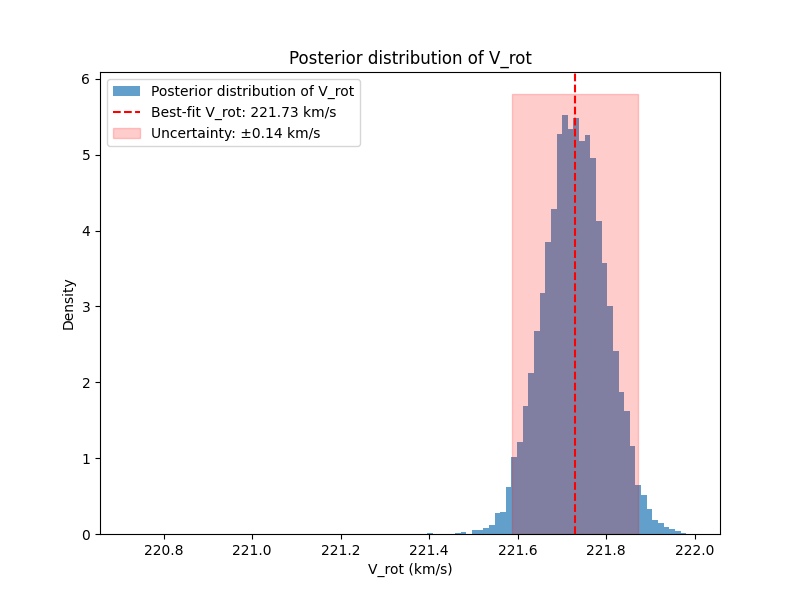

In [13]:
# hist of v_rot computed values

plt.figure(figsize=(8, 6))
plt.hist(samples[:, 0], bins=100, density=True, alpha=0.7, label="Posterior distribution of V_rot")

# plot the best-fit value as a vertical line
plt.axvline(V_rot_best, color='r', linestyle='--', label=f"Best-fit V_rot: {V_rot_best:.2f} km/s")

# plot the uncertainty as a shaded region
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], V_rot_best - V_rot_uncertainty, V_rot_best + V_rot_uncertainty, color='r', alpha=0.2, label=f"Uncertainty: ±{V_rot_uncertainty:.2f} km/s")

plt.legend()
plt.xlabel("V_rot (km/s)")
plt.ylabel("Density")
plt.title("Posterior distribution of V_rot")
plt.show()

### Corner plot

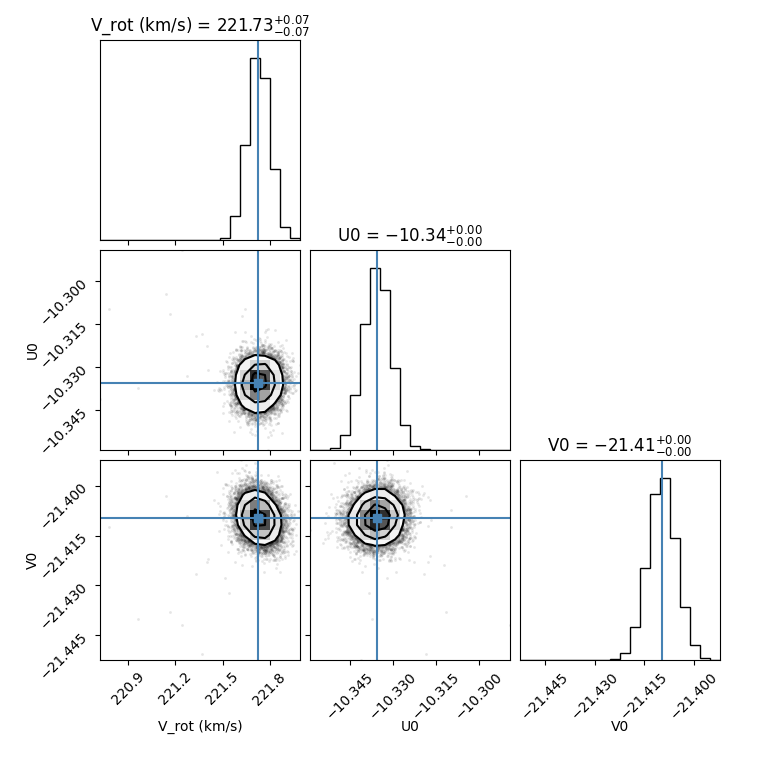

In [14]:
fig = corner.corner(
    samples, 
    labels=["V_rot (km/s)", "U0", "V0"], 
    truths=[V_rot_best, U0_best, V0_best], 
    show_titles=True
)

### Trace plot

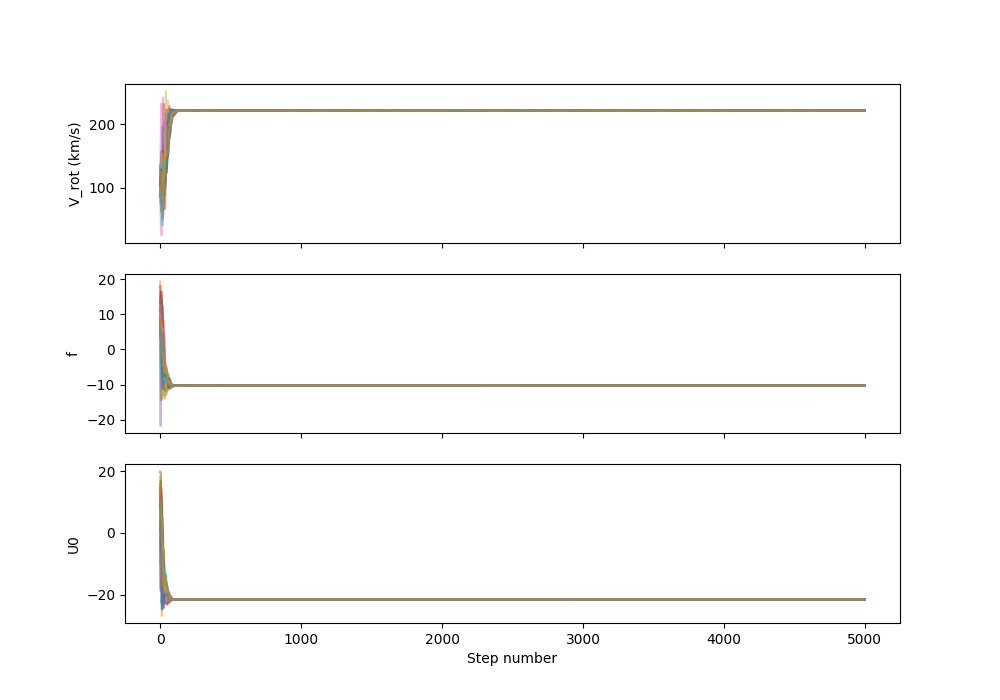

In [15]:
# trace plot to check for convergence for both parameters
fig, axes = plt.subplots(dim, figsize=(10, 7), sharex=True)
samples_chain = sampler.get_chain()

parameter_labels = ["V_rot (km/s)", "f", "U0", "V0 (km/s)"]

for i in range(dim):
    ax = axes[i]
    for walker in range(nwal):
        ax.plot(samples_chain[:, walker, i], alpha=0.5)
    ax.set_ylabel(f"{parameter_labels[i]}")

axes[-1].set_xlabel("Step number")

plt.show()

### Comparison

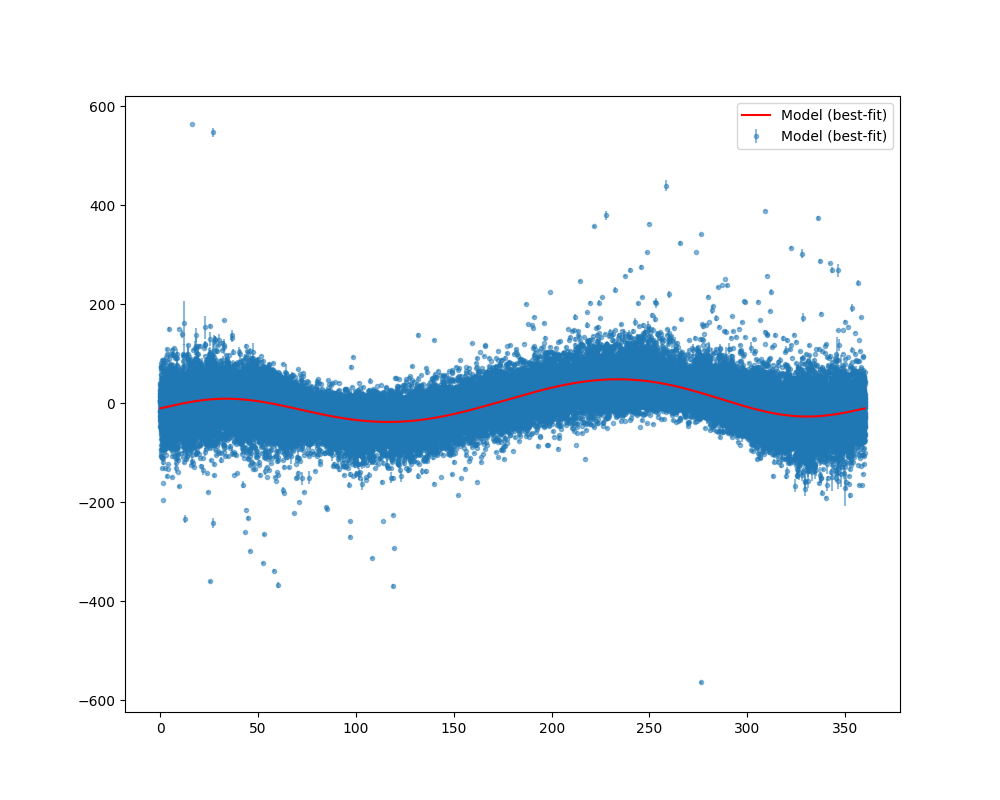

In [29]:
fig = plt.figure(figsize=(10, 8))

# plot the observed data
#plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
sigma = np.sqrt((model_derivative(l_rad, R0, V_rot_best, d_from_sun, distance_from_gc(l_rad, d_from_sun, R0), parallax) * parallax_error)**2 + radial_velocity_error**2)    # total uncertainty (model + measurement)
plt.errorbar(l, radial_velocity, yerr=sigma, fmt='.', label="Model (best-fit)", zorder=1, alpha=0.5)


# plot the model with the best-fit parameters

avg_dist_from_sun = np.mean(d_from_sun)

l_vals_vals = np.linspace(0, 2*np.pi, 1000)
l_vals_deg = np.degrees(l_vals_vals)
V_rad_exp = velocity_model(l_vals_vals, avg_dist_from_sun, R0, V_rot_best, U0_best, V0_best)
plt.plot(l_vals_deg, V_rad_exp, label="Model (best-fit)", color="red", zorder=2)

plt.legend()
plt.show()

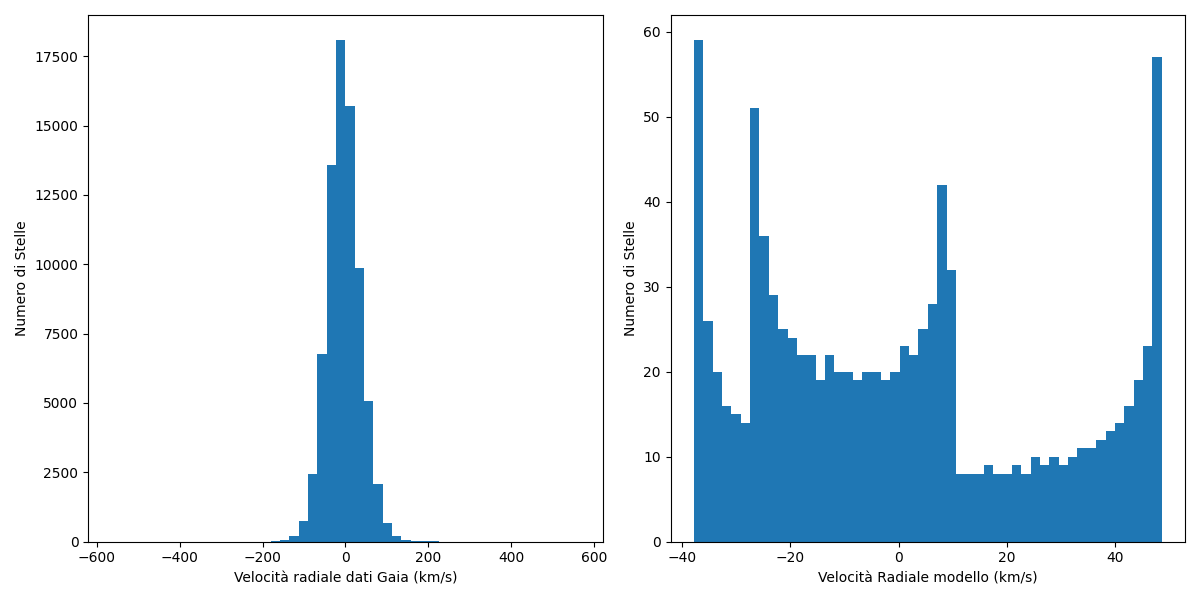

In [30]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(radial_velocity, bins=50)
plt.xlabel("Velocità radiale dati Gaia (km/s)")
plt.ylabel("Numero di Stelle")
#plt.title("Distribution of Radial Velocities (Data)")

plt.subplot(1, 2, 2)
plt.hist(V_rad_exp, bins=50)
plt.xlabel("Velocità Radiale modello (km/s)")
plt.ylabel("Numero di Stelle")
#plt.title("Distribution of Radial Velocities (Model)")

plt.tight_layout()
plt.show()

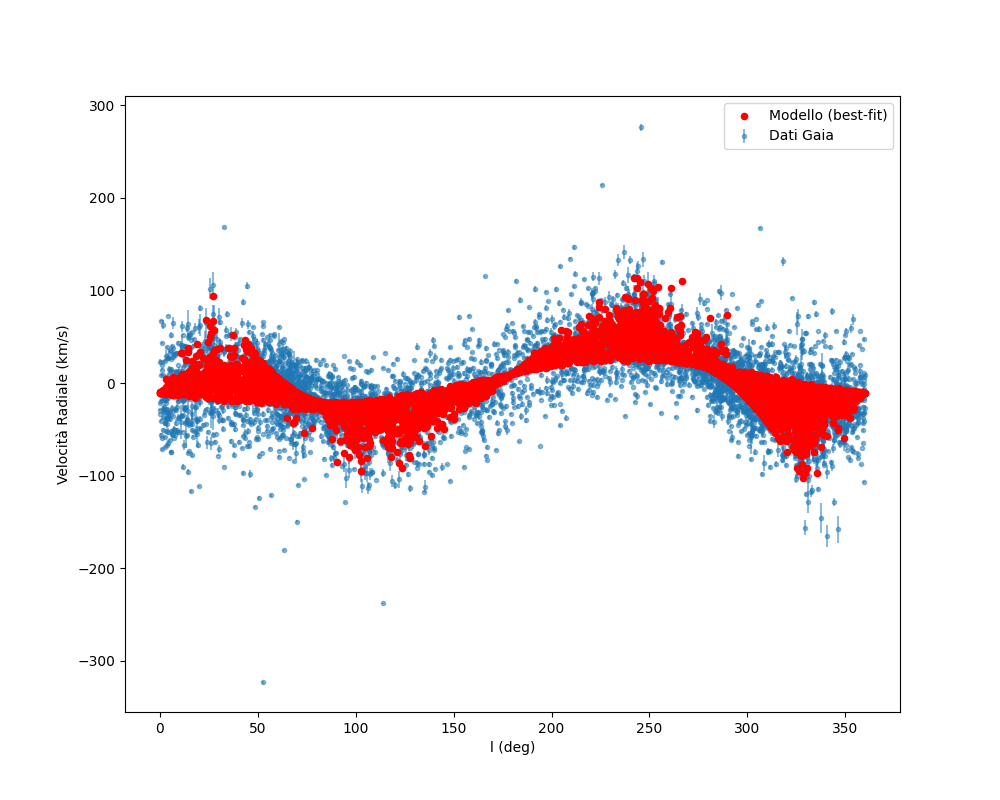

In [28]:
num_samples = 5000

sample_inds = np.random.choice(len(radial_velocity), num_samples, replace=False)
vel_rad_sampled = radial_velocity[sample_inds]
l_sampled = l[sample_inds]
d_sampled = d_from_sun[sample_inds]
parallax_sampled = parallax[sample_inds]
parallax_error_sampled = parallax_error[sample_inds]
radial_velocity_error_sampled = radial_velocity_error[sample_inds]
sigma_sampled = sigma[sample_inds]
V_rad_statistical_error_sampled = V_rad_statistical_error[sample_inds]
v_rad_exp = velocity_model(np.radians(l_sampled), d_sampled, R0, V_rot_best, U0_best, V0_best)


fig = plt.figure(figsize=(10, 8))

# plot the observed data
plt.errorbar(l_sampled, vel_rad_sampled, yerr=sigma_sampled, fmt='.', label="Dati Gaia", zorder=1, alpha=0.5)
plt.scatter(l_sampled, v_rad_exp, s=20, label="Modello (best-fit)", color="red", zorder=2)
# plot the model with the best-fit parameters
plt.xlabel("l (deg)")
plt.ylabel("Velocità Radiale (km/s)")

plt.legend()
plt.show()